# PARP-1 Inhibitor Activity Prediction
## Progress Report 2 — Imbalance Strategy Comparison

| Strategy | Description |
|---|---|
| **No Handling** | Train on raw imbalanced data (75% active / 25% inactive) — baseline |
| **Focal Loss** | Dynamically down-weights easy examples, focuses model on hard cases |
| **Loss Weighting** | Inverse-frequency class weights applied directly to the loss function |

**Key metrics reported:** ROC-AUC, PR-AUC, F1, Recall (sensitivity), **Specificity (inactive recall)**, Balanced Accuracy, MCC

## CELL 1 — Install

In [1]:
# Run once, then restart runtime
!pip install rdkit torch torchvision torchaudio --quiet
!pip install torch_geometric --quiet
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 65.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.2 MB/s eta 0:00:00


## CELL 2 — Imports & Config

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from collections import defaultdict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, matthews_corrcoef,
    balanced_accuracy_score, roc_curve, precision_recall_curve
)
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from xgboost import XGBClassifier

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Mounted at /content/drive
Device: cuda


## CELL 3 — Load Data

In [3]:
DATA_PATH = '/content/drive/MyDrive/junior_project/dataset_clean.csv'

df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['Ligand SMILES', 'activity']).reset_index(drop=True)

n_active   = int((df.activity == 1).sum())
n_inactive = int((df.activity == 0).sum())
n_total    = len(df)

print(f'Total:    {n_total}')
print(f'Active:   {n_active}  ({n_active/n_total*100:.1f}%)')
print(f'Inactive: {n_inactive}  ({n_inactive/n_total*100:.1f}%)')
print(f'Imbalance ratio: {n_active/n_inactive:.2f}:1')

SMILES_ALL = df['Ligand SMILES'].tolist()
LABELS_ALL = df['activity'].values

Total:    5072
Active:   3818  (75.3%)
Inactive: 1254  (24.7%)
Imbalance ratio: 3.04:1


## CELL 4 — Scaffold Split

In [4]:
def get_scaffold(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

scaffolds = [get_scaffold(s) for s in SMILES_ALL]
scaffold_to_idx = defaultdict(list)
for i, sc in enumerate(scaffolds):
    if sc is not None:
        scaffold_to_idx[sc].append(i)

# Sort scaffold clusters largest-first, allocate to test until 20% full
scaffold_sets = sorted(scaffold_to_idx.values(), key=len, reverse=True)
train_idx, test_idx = [], []
test_frac = 0.20

for scaffold_idxs in scaffold_sets:
    if len(test_idx) / max(n_total, 1) < test_frac:
        test_idx.extend(scaffold_idxs)
    else:
        train_idx.extend(scaffold_idxs)

SMILES_TRAIN = [SMILES_ALL[i] for i in train_idx]
SMILES_TEST  = [SMILES_ALL[i] for i in test_idx]
Y_TRAIN      = LABELS_ALL[train_idx]
Y_TEST       = LABELS_ALL[test_idx]

n_tr_pos = int((Y_TRAIN == 1).sum())
n_tr_neg = int((Y_TRAIN == 0).sum())

print(f'Train: {len(SMILES_TRAIN)} | Test: {len(SMILES_TEST)}')
print(f'Train — Active: {n_tr_pos} ({n_tr_pos/len(SMILES_TRAIN)*100:.1f}%) | Inactive: {n_tr_neg} ({n_tr_neg/len(SMILES_TRAIN)*100:.1f}%)')
print(f'Test  — Active: {int((Y_TEST==1).sum())} | Inactive: {int((Y_TEST==0).sum())}')

[19:52:24] Can't kekulize mol.  Unkekulized atoms: 16 17 18 19 21
[19:52:24] Explicit valence for atom # 5 N, 4, is greater than permitted


Train: 4030 | Test: 1040
Train — Active: 3050 (75.7%) | Inactive: 980 (24.3%)
Test  — Active: 768 | Inactive: 272


## CELL 5 — Shared Utilities

In [5]:
# ── Morgan Fingerprints ──────────────────────────────────────────────
def smiles_to_fp(smiles_list, radius=3, n_bits=2048):
    fps, valid_idx = [], []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
            fps.append(list(fp))
            valid_idx.append(i)
    return np.array(fps, dtype=np.float32), valid_idx

# ── Metrics (includes specificity, balanced accuracy, MCC) ───────────
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return {
        'ROC-AUC':     round(roc_auc_score(y_true, y_prob), 4),
        'PR-AUC':      round(average_precision_score(y_true, y_prob), 4),
        'Accuracy':    round(accuracy_score(y_true, y_pred), 4),
        'Precision':   round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':      round(recall_score(y_true, y_pred), 4),
        'Specificity': round(specificity, 4),
        'F1':          round(f1_score(y_true, y_pred), 4),
        'Bal_Acc':     round(balanced_accuracy_score(y_true, y_pred), 4),
        'MCC':         round(matthews_corrcoef(y_true, y_pred), 4),
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn),
        'probs': y_prob, 'y_true': y_true
    }

# ── Atom features for GNN ────────────────────────────────────────────
def atom_features(atom):
    return [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        int(atom.GetHybridization()),
        int(atom.GetIsAromatic()),
        atom.GetTotalNumHs(),
    ]

def mol_to_graph(smi, label):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float)
    edge_index = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index += [[i, j], [j, i]]
    if not edge_index:
        return None
    ei = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    y  = torch.tensor([label], dtype=torch.float)
    return Data(x=x, edge_index=ei, y=y)

print('Utilities loaded.')

Utilities loaded.


## CELL 6 — Strategy Setup & Loss Functions

In [6]:
# ─────────────────────────────────────────────────────────────────────
# STRATEGY DEFINITIONS
# ─────────────────────────────────────────────────────────────────────
#
# 1. No Handling:
#    Standard BCE. Model sees 75% active → biased toward majority.
#
# 2. Focal Loss:
#    FL = -alpha_t * (1 - p_t)^gamma * log(p_t)
#    Down-weights easy (high-confidence) examples, forcing the model
#    to focus on hard misclassified cases. Uses alpha to balance classes.
#    gamma=2 is standard. Limitation: "hard" examples may be structural
#    outliers, not necessarily the inactive minority class.
#
# 3. Loss Weighting (proposed best approach):
#    BCE with pos_weight = n_inactive / n_active < 1.
#    This DIRECTLY reduces the loss contribution from the majority
#    (active) class, making each inactive sample contribute relatively
#    more to the gradient. The correction is principled and stable.
# ─────────────────────────────────────────────────────────────────────

# Inverse-frequency weight for Loss Weighting
# pos_weight < 1 → penalises active (majority) class less → network
# is forced to be more careful about inactive predictions
LW_POS_WEIGHT = n_tr_neg / n_tr_pos          # ≈ 0.33
LW_XGB_SPW    = LW_POS_WEIGHT                # same ratio for XGBoost

# Focal Loss class alphas (frequency-inverse)
FL_ALPHA_POS = n_tr_neg / (n_tr_pos + n_tr_neg)   # ≈ 0.25 — active class
FL_ALPHA_NEG = n_tr_pos / (n_tr_pos + n_tr_neg)   # ≈ 0.75 — inactive class
FL_GAMMA     = 2.0

print(f'Loss Weighting — pos_weight:   {LW_POS_WEIGHT:.4f}')
print(f'Focal Loss     — alpha_active: {FL_ALPHA_POS:.4f}, alpha_inactive: {FL_ALPHA_NEG:.4f}, gamma: {FL_GAMMA}')

STRATEGIES = ['No Handling', 'Loss Weighting', 'Focal Loss']

# ── Focal Loss implementation ─────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Binary Focal Loss.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    alpha_pos : weight for POSITIVE (active) samples
    alpha_neg : weight for NEGATIVE (inactive) samples
    gamma     : focusing exponent (0 = standard weighted BCE, 2 = standard FL)
    """
    def __init__(self, alpha_pos=0.25, alpha_neg=0.75, gamma=2.0):
        super().__init__()
        self.alpha_pos = alpha_pos
        self.alpha_neg = alpha_neg
        self.gamma     = gamma

    def forward(self, logits, targets):
        probs   = torch.sigmoid(logits)
        p_t     = probs * targets + (1 - probs) * (1 - targets)          # p of true class
        alpha_t = self.alpha_pos * targets + self.alpha_neg * (1 - targets)
        focal_w = (1.0 - p_t) ** self.gamma
        bce     = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        return (alpha_t * focal_w * bce).mean()


def get_loss_fn(strategy):
    """Return the appropriate loss function for a given strategy."""
    if strategy == 'No Handling':
        return nn.BCEWithLogitsLoss()
    elif strategy == 'Loss Weighting':
        pw = torch.tensor([LW_POS_WEIGHT], dtype=torch.float).to(DEVICE)
        return nn.BCEWithLogitsLoss(pos_weight=pw)
    elif strategy == 'Focal Loss':
        return FocalLoss(alpha_pos=FL_ALPHA_POS, alpha_neg=FL_ALPHA_NEG, gamma=FL_GAMMA).to(DEVICE)
    else:
        raise ValueError(f'Unknown strategy: {strategy}')


def xgb_scale_pos_weight(strategy):
    """scale_pos_weight for XGBoost component of the Hybrid model."""
    if strategy == 'No Handling':
        return 1.0
    # Both Loss Weighting and Focal Loss use inverse-frequency weighting
    # (XGBoost does not natively support focal loss)
    return LW_XGB_SPW


ALL_RESULTS          = defaultdict(dict)
GNN_PROBS_PER_STRAT  = {}

print('Strategy config ready.')

Loss Weighting — pos_weight:   0.3213
Focal Loss     — alpha_active: 0.2432, alpha_inactive: 0.7568, gamma: 2.0
Strategy config ready.


## CELL 7 — Model Definitions (MLP & GNN)

In [7]:
class ChemMLP(nn.Module):
    """3-layer MLP operating on 2048-bit Morgan fingerprints."""
    def __init__(self, input_dim=2048):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


class ChemGNN(nn.Module):
    """3-layer Graph Convolutional Network on molecular graphs."""
    def __init__(self, node_dim=6, hidden=128):
        super().__init__()
        self.conv1 = GCNConv(node_dim, hidden)
        self.conv2 = GCNConv(hidden,   hidden)
        self.conv3 = GCNConv(hidden,   hidden)
        self.bn1   = nn.BatchNorm1d(hidden)
        self.bn2   = nn.BatchNorm1d(hidden)
        self.bn3   = nn.BatchNorm1d(hidden)
        self.head  = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 1)
        )
    def forward(self, x, edge_index, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        x = global_mean_pool(x, batch)
        return self.head(x).squeeze(-1)

print('Model definitions ready.')

Model definitions ready.


## CELL 8 — MLP Training Function

In [8]:
def train_eval_mlp(strategy):
    Xtr, tr_v = smiles_to_fp(SMILES_TRAIN)
    Xte, te_v = smiles_to_fp(SMILES_TEST)
    ytr = Y_TRAIN[tr_v].astype(np.float32)
    yte = Y_TEST[te_v]

    ds  = TensorDataset(torch.tensor(Xtr), torch.tensor(ytr))
    dl  = DataLoader(ds, batch_size=256, shuffle=True, drop_last=True)

    model     = ChemMLP().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60)
    criterion = get_loss_fn(strategy)

    for epoch in range(60):
        model.train()
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()
        scheduler.step()

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(torch.tensor(Xte).to(DEVICE))).cpu().numpy()

    m = compute_metrics(yte, probs)
    ALL_RESULTS[strategy]['MLP'] = m
    return m

## CELL 9 — Run MLP × 3 Strategies

In [9]:
for strat in STRATEGIES:
    print(f'\n>>> MLP — {strat}')
    m = train_eval_mlp(strat)
    print(f"    ROC-AUC={m['ROC-AUC']:.4f}  F1={m['F1']:.4f}  "
          f"Recall={m['Recall']:.4f}  Specificity={m['Specificity']:.4f}  MCC={m['MCC']:.4f}")


>>> MLP — No Handling


Streaming output truncated to the last 5000 lines.
[19:52:28] DEPRECATION WARNING: please use MorganGenerator
[19:52:28] DEPRECATION WARNING: please use MorganGenerator
[19:52:28] DEPRECATION WARNING: please use MorganGenerator
[19:52:28] DEPRECATION WARNING: please use MorganGenerator
[19:52:28] DEPRECATION WARNING: please use MorganGenerator
[19:52:28] DEPRECATION WARNING: please use MorganGenerator
[19:52:28] DEPRECATION WARNING: please use MorganGenerator
[19:52:28] DEPRECATION WARNING: please use MorganGenerator
[19:52:28] DEPRECATION WARNING: please use MorganGenerator
[19:52:28] DEPRECATION WARNING: please use MorganGenerator
[19:52:28] DEPRECATION WARNING: please use MorganGenerator
[19:52:28] DEPRECATION WARNING: please use MorganGenerator
[19:52:28] DEPRECATION WARNING: please use MorganGenerator
[19:52:28] DEPRECATION WARNING: please use MorganGenerator
[19:52:28] DEPRECATION WARNING: please use MorganGenerator
[19:52:28] DEPRECATION WARNING: please use MorganGenerator
[19:5

    ROC-AUC=0.8883  F1=0.8858  Recall=0.8841  Specificity=0.6838  MCC=0.5659

>>> MLP — Loss Weighting


Streaming output truncated to the last 5000 lines.
[19:52:52] DEPRECATION WARNING: please use MorganGenerator
[19:52:52] DEPRECATION WARNING: please use MorganGenerator
[19:52:52] DEPRECATION WARNING: please use MorganGenerator
[19:52:52] DEPRECATION WARNING: please use MorganGenerator
[19:52:52] DEPRECATION WARNING: please use MorganGenerator
[19:52:52] DEPRECATION WARNING: please use MorganGenerator
[19:52:52] DEPRECATION WARNING: please use MorganGenerator
[19:52:52] DEPRECATION WARNING: please use MorganGenerator
[19:52:52] DEPRECATION WARNING: please use MorganGenerator
[19:52:52] DEPRECATION WARNING: please use MorganGenerator
[19:52:52] DEPRECATION WARNING: please use MorganGenerator
[19:52:52] DEPRECATION WARNING: please use MorganGenerator
[19:52:52] DEPRECATION WARNING: please use MorganGenerator
[19:52:52] DEPRECATION WARNING: please use MorganGenerator
[19:52:52] DEPRECATION WARNING: please use MorganGenerator
[19:52:52] DEPRECATION WARNING: please use MorganGenerator
[19:5

    ROC-AUC=0.8894  F1=0.8808  Recall=0.8516  Specificity=0.7684  MCC=0.5888

>>> MLP — Focal Loss


Streaming output truncated to the last 5000 lines.
[19:53:03] DEPRECATION WARNING: please use MorganGenerator
[19:53:03] DEPRECATION WARNING: please use MorganGenerator
[19:53:03] DEPRECATION WARNING: please use MorganGenerator
[19:53:03] DEPRECATION WARNING: please use MorganGenerator
[19:53:03] DEPRECATION WARNING: please use MorganGenerator
[19:53:03] DEPRECATION WARNING: please use MorganGenerator
[19:53:03] DEPRECATION WARNING: please use MorganGenerator
[19:53:03] DEPRECATION WARNING: please use MorganGenerator
[19:53:03] DEPRECATION WARNING: please use MorganGenerator
[19:53:03] DEPRECATION WARNING: please use MorganGenerator
[19:53:03] DEPRECATION WARNING: please use MorganGenerator
[19:53:03] DEPRECATION WARNING: please use MorganGenerator
[19:53:03] DEPRECATION WARNING: please use MorganGenerator
[19:53:03] DEPRECATION WARNING: please use MorganGenerator
[19:53:03] DEPRECATION WARNING: please use MorganGenerator
[19:53:03] DEPRECATION WARNING: please use MorganGenerator
[19:5

    ROC-AUC=0.8873  F1=0.8779  Recall=0.8659  Specificity=0.6985  MCC=0.5514


## CELL 10 — GNN Training Function

In [10]:
def build_graphs(smi_list, label_arr):
    graphs, labels_out = [], []
    for smi, lbl in zip(smi_list, label_arr):
        g = mol_to_graph(smi, lbl)
        if g:
            graphs.append(g)
            labels_out.append(lbl)
    return graphs, np.array(labels_out)

# Build test graphs once — shared across all strategies
TEST_GRAPHS, Y_TEST_GNN = build_graphs(SMILES_TEST, Y_TEST)
TEST_GEO_DL = GeoDataLoader(TEST_GRAPHS, batch_size=256, shuffle=False)

def train_eval_gnn(strategy):
    graphs, y_tr = build_graphs(SMILES_TRAIN, Y_TRAIN)
    train_dl     = GeoDataLoader(graphs, batch_size=128, shuffle=True)

    model     = ChemGNN().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60)
    criterion = get_loss_fn(strategy)

    for epoch in range(60):
        model.train()
        for batch in train_dl:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            out  = model(batch.x, batch.edge_index, batch.batch)
            criterion(out, batch.y.squeeze()).backward()
            optimizer.step()
        scheduler.step()

    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch in TEST_GEO_DL:
            batch = batch.to(DEVICE)
            out   = model(batch.x, batch.edge_index, batch.batch)
            all_probs.extend(torch.sigmoid(out).cpu().numpy())

    probs = np.array(all_probs)
    m = compute_metrics(Y_TEST_GNN, probs)
    ALL_RESULTS[strategy]['GNN']          = m
    GNN_PROBS_PER_STRAT[strategy]         = (probs, Y_TEST_GNN)
    return m

print('GNN utilities ready.')

GNN utilities ready.


## CELL 11 — Run GNN × 3 Strategies

In [11]:
for strat in STRATEGIES:
    print(f'\n>>> GNN — {strat}')
    m = train_eval_gnn(strat)
    print(f"    ROC-AUC={m['ROC-AUC']:.4f}  F1={m['F1']:.4f}  "
          f"Recall={m['Recall']:.4f}  Specificity={m['Specificity']:.4f}  MCC={m['MCC']:.4f}")


>>> GNN — No Handling
    ROC-AUC=0.9041  F1=0.8903  Recall=0.9297  Specificity=0.5515  MCC=0.5325

>>> GNN — Loss Weighting
    ROC-AUC=0.8993  F1=0.8866  Recall=0.8451  Specificity=0.8272  MCC=0.6279

>>> GNN — Focal Loss
    ROC-AUC=0.8997  F1=0.8865  Recall=0.8542  Specificity=0.7941  MCC=0.6131


## CELL 12 — Hybrid Training Function (XGBoost + GNN Ensemble)

In [12]:
def train_eval_hybrid(strategy):
    # ── XGBoost on Morgan fingerprints ──────────────────────────────
    Xtr, tr_v = smiles_to_fp(SMILES_TRAIN)
    Xte, te_v = smiles_to_fp(SMILES_TEST)
    ytr = Y_TRAIN[tr_v]
    yte = Y_TEST[te_v]

    xgb = XGBClassifier(
        n_estimators      = 300,
        max_depth         = 6,
        learning_rate     = 0.05,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        scale_pos_weight  = xgb_scale_pos_weight(strategy),
        use_label_encoder = False,
        eval_metric       = 'logloss',
        random_state      = 42,
        tree_method       = 'hist',
        device            = 'cuda' if torch.cuda.is_available() else 'cpu'
    )
    xgb.fit(Xtr, ytr, verbose=False)
    xgb_probs = xgb.predict_proba(Xte)[:, 1]

    # ── GNN probs (computed in GNN cell) ────────────────────────────
    gnn_probs, gnn_yte = GNN_PROBS_PER_STRAT[strategy]

    # Align test sets (both should be the same, but handle edge cases)
    min_len   = min(len(xgb_probs), len(gnn_probs), len(yte))
    xgb_probs = xgb_probs[:min_len]
    gnn_probs = gnn_probs[:min_len]
    yte       = yte[:min_len]

    # ── Ensemble: simple average of probabilities ────────────────────
    ensemble_probs = (xgb_probs + gnn_probs) / 2.0

    m = compute_metrics(yte, ensemble_probs)
    ALL_RESULTS[strategy]['Hybrid'] = m
    return m

print('Hybrid function ready.')

Hybrid function ready.


## CELL 13 — Run Hybrid × 3 Strategies

In [13]:
for strat in STRATEGIES:
    print(f'\n>>> Hybrid — {strat}')
    m = train_eval_hybrid(strat)
    print(f"    ROC-AUC={m['ROC-AUC']:.4f}  F1={m['F1']:.4f}  "
          f"Recall={m['Recall']:.4f}  Specificity={m['Specificity']:.4f}  MCC={m['MCC']:.4f}")


>>> Hybrid — No Handling


Streaming output truncated to the last 5000 lines.
[19:54:32] DEPRECATION WARNING: please use MorganGenerator
[19:54:32] DEPRECATION WARNING: please use MorganGenerator
[19:54:32] DEPRECATION WARNING: please use MorganGenerator
[19:54:32] DEPRECATION WARNING: please use MorganGenerator
[19:54:32] DEPRECATION WARNING: please use MorganGenerator
[19:54:32] DEPRECATION WARNING: please use MorganGenerator
[19:54:32] DEPRECATION WARNING: please use MorganGenerator
[19:54:32] DEPRECATION WARNING: please use MorganGenerator
[19:54:32] DEPRECATION WARNING: please use MorganGenerator
[19:54:32] DEPRECATION WARNING: please use MorganGenerator
[19:54:32] DEPRECATION WARNING: please use MorganGenerator
[19:54:32] DEPRECATION WARNING: please use MorganGenerator
[19:54:32] DEPRECATION WARNING: please use MorganGenerator
[19:54:32] DEPRECATION WARNING: please use MorganGenerator
[19:54:32] DEPRECATION WARNING: please use MorganGenerator
[19:54:32] DEPRECATION WARNING: please use MorganGenerator
[19:5

    ROC-AUC=0.9182  F1=0.9002  Recall=0.9518  Specificity=0.5404  MCC=0.5669

>>> Hybrid — Loss Weighting


Streaming output truncated to the last 5000 lines.
[19:54:40] DEPRECATION WARNING: please use MorganGenerator
[19:54:40] DEPRECATION WARNING: please use MorganGenerator
[19:54:40] DEPRECATION WARNING: please use MorganGenerator
[19:54:40] DEPRECATION WARNING: please use MorganGenerator
[19:54:40] DEPRECATION WARNING: please use MorganGenerator
[19:54:40] DEPRECATION WARNING: please use MorganGenerator
[19:54:40] DEPRECATION WARNING: please use MorganGenerator
[19:54:40] DEPRECATION WARNING: please use MorganGenerator
[19:54:40] DEPRECATION WARNING: please use MorganGenerator
[19:54:40] DEPRECATION WARNING: please use MorganGenerator
[19:54:40] DEPRECATION WARNING: please use MorganGenerator
[19:54:40] DEPRECATION WARNING: please use MorganGenerator
[19:54:40] DEPRECATION WARNING: please use MorganGenerator
[19:54:40] DEPRECATION WARNING: please use MorganGenerator
[19:54:40] DEPRECATION WARNING: please use MorganGenerator
[19:54:40] DEPRECATION WARNING: please use MorganGenerator
[19:5

    ROC-AUC=0.9170  F1=0.9071  Recall=0.8646  Specificity=0.8824  MCC=0.6977

>>> Hybrid — Focal Loss


Streaming output truncated to the last 5000 lines.
[19:54:49] DEPRECATION WARNING: please use MorganGenerator
[19:54:49] DEPRECATION WARNING: please use MorganGenerator
[19:54:49] DEPRECATION WARNING: please use MorganGenerator
[19:54:49] DEPRECATION WARNING: please use MorganGenerator
[19:54:49] DEPRECATION WARNING: please use MorganGenerator
[19:54:49] DEPRECATION WARNING: please use MorganGenerator
[19:54:49] DEPRECATION WARNING: please use MorganGenerator
[19:54:49] DEPRECATION WARNING: please use MorganGenerator
[19:54:49] DEPRECATION WARNING: please use MorganGenerator
[19:54:49] DEPRECATION WARNING: please use MorganGenerator
[19:54:49] DEPRECATION WARNING: please use MorganGenerator
[19:54:49] DEPRECATION WARNING: please use MorganGenerator
[19:54:49] DEPRECATION WARNING: please use MorganGenerator
[19:54:49] DEPRECATION WARNING: please use MorganGenerator
[19:54:49] DEPRECATION WARNING: please use MorganGenerator
[19:54:49] DEPRECATION WARNING: please use MorganGenerator
[19:5

    ROC-AUC=0.9208  F1=0.8915  Recall=0.8346  Specificity=0.8934  MCC=0.6683


---
# RESULTS & FIGURES
## CELL 14 — Full Results Table & CSV Export

In [14]:
MODEL_LIST = ['MLP', 'GNN', 'Hybrid']
REPORT_COLS = ['Strategy', 'Model', 'ROC-AUC', 'PR-AUC', 'Accuracy',
               'Precision', 'Recall', 'Specificity', 'F1', 'Bal_Acc', 'MCC']

rows = []
for strat in STRATEGIES:
    for model in MODEL_LIST:
        m = ALL_RESULTS[strat][model]
        rows.append({c: (strat if c=='Strategy' else model if c=='Model' else m[c])
                     for c in REPORT_COLS})

results_df = pd.DataFrame(rows)

# Pretty-print
print('='*90)
print(results_df.to_string(index=False))
print('='*90)

# Naive-classifier comparison
naive_f1  = 2 * 0.75 / (0.75 + 1.0)  # always predicts active
best_mcc  = results_df['MCC'].max()
best_spec = results_df['Specificity'].max()
best_row  = results_df.loc[results_df['MCC'].idxmax()]
print(f'\nNaive classifier (always active)  F1={naive_f1:.4f}')
print(f'Best model: {best_row["Strategy"]} / {best_row["Model"]}  '
      f'F1={best_row["F1"]:.4f}  MCC={best_row["MCC"]:.4f}  Specificity={best_row["Specificity"]:.4f}')

# Save
results_df.to_csv('/content/drive/MyDrive/junior_project/model_results_v2.csv', index=False)
print('\nResults saved to model_results_v2.csv')

      Strategy  Model  ROC-AUC  PR-AUC  Accuracy  Precision  Recall  Specificity     F1  Bal_Acc    MCC
   No Handling    MLP   0.8883  0.9479    0.8317     0.8876  0.8841       0.6838 0.8858   0.7840 0.5659
   No Handling    GNN   0.9041  0.9550    0.8308     0.8541  0.9297       0.5515 0.8903   0.7406 0.5325
   No Handling Hybrid   0.9182  0.9575    0.8442     0.8540  0.9518       0.5404 0.9002   0.7461 0.5669
Loss Weighting    MLP   0.8894  0.9475    0.8298     0.9121  0.8516       0.7684 0.8808   0.8100 0.5888
Loss Weighting    GNN   0.8993  0.9531    0.8404     0.9325  0.8451       0.8272 0.8866   0.8361 0.6279
Loss Weighting Hybrid   0.9170  0.9580    0.8692     0.9540  0.8646       0.8824 0.9071   0.8735 0.6977
    Focal Loss    MLP   0.8873  0.9494    0.8221     0.8902  0.8659       0.6985 0.8779   0.7822 0.5514
    Focal Loss    GNN   0.8997  0.9576    0.8385     0.9213  0.8542       0.7941 0.8865   0.8241 0.6131
    Focal Loss Hybrid   0.9208  0.9630    0.8500     0.9567  0.8

## CELL 15 — Figure 1: Strategy Effect per Model

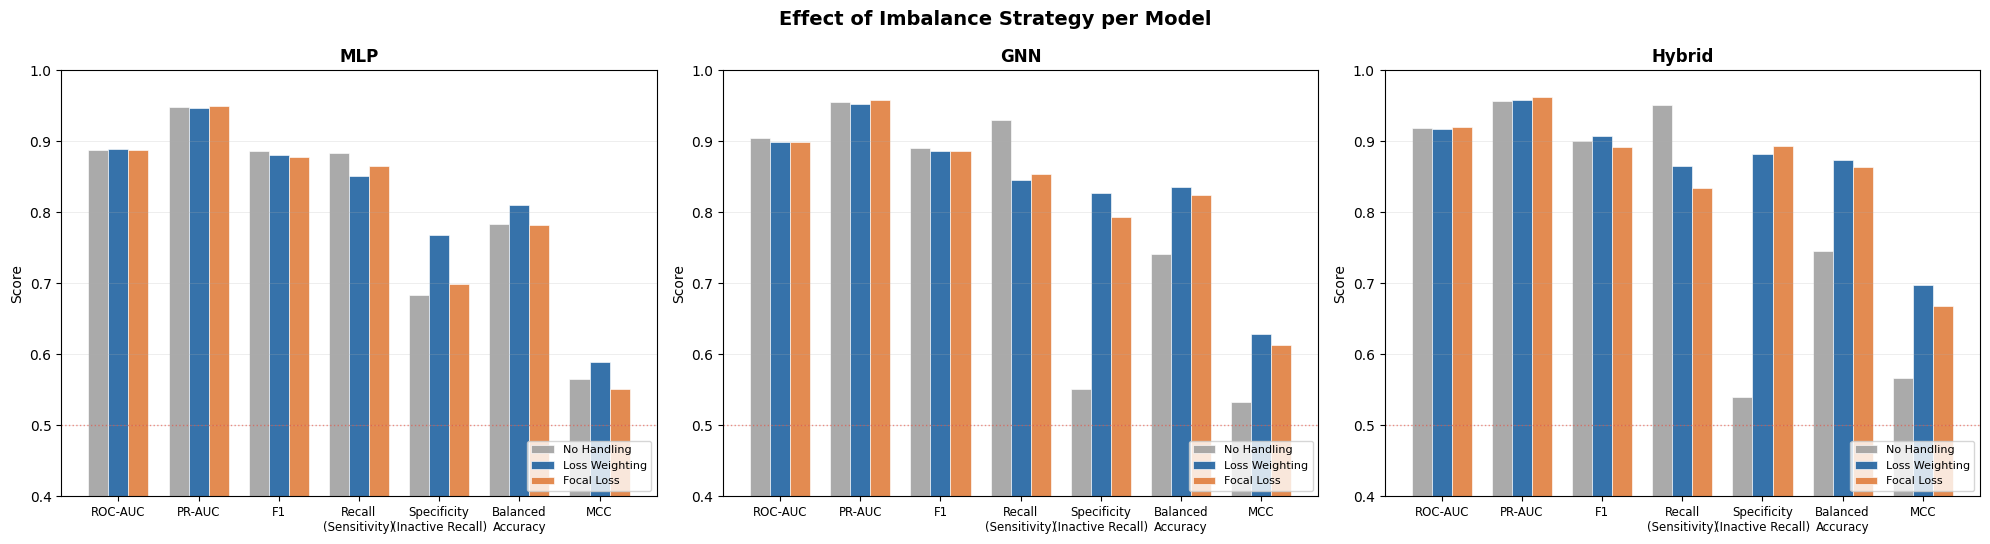

Figure 1 saved.


In [15]:
STRAT_COLORS = {
    'No Handling':    '#9E9E9E',   # gray
    'Focal Loss':     '#E07B39',   # amber
    'Loss Weighting': '#1A5E9E',   # blue
}
MODEL_COLORS = {'MLP': '#4A90D9', 'GNN': '#2D8C5E', 'Hybrid': '#8E44AD'}

# ── Figure 1: Strategy comparison per model ──────────────────────────
metric_keys   = ['ROC-AUC', 'PR-AUC', 'F1', 'Recall', 'Specificity', 'Bal_Acc', 'MCC']
metric_labels = ['ROC-AUC', 'PR-AUC', 'F1', 'Recall\n(Sensitivity)',
                 'Specificity\n(Inactive Recall)', 'Balanced\nAccuracy', 'MCC']
x     = np.arange(len(metric_keys))
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), sharey=False)
fig.suptitle('Effect of Imbalance Strategy per Model', fontsize=14, fontweight='bold')

for ax, model in zip(axes, MODEL_LIST):
    for j, strat in enumerate(STRATEGIES):
        vals = [ALL_RESULTS[strat][model][k] for k in metric_keys]
        ax.bar(x + (j - 1) * width, vals, width,
               label=strat, color=STRAT_COLORS[strat], alpha=0.88,
               edgecolor='white', linewidth=0.5)
    ax.set_title(model, fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=8.5)
    ax.set_ylim(0.40, 1.0)
    ax.set_ylabel('Score')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)
    # Mark random-chance for Specificity (should be ~0.5 without handling)
    ax.axhline(y=0.50, color='#E74C3C', linestyle=':', linewidth=1.0, alpha=0.6)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/junior_project/fig1_strategy_per_model.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## CELL 16 — Figure 2: Model Comparison per Strategy

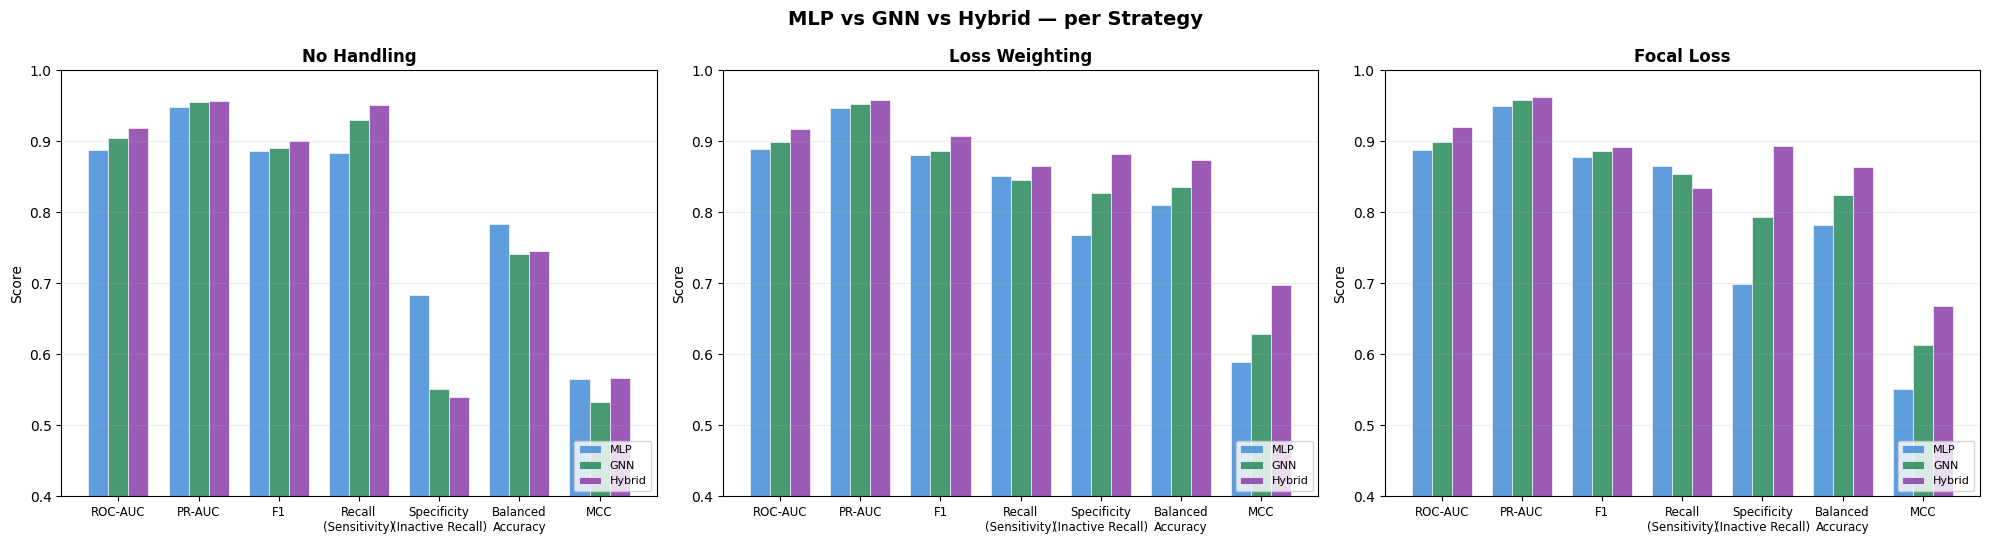

Figure 2 saved.


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), sharey=False)
fig.suptitle('MLP vs GNN vs Hybrid — per Strategy', fontsize=14, fontweight='bold')

for ax, strat in zip(axes, STRATEGIES):
    for j, model in enumerate(MODEL_LIST):
        vals = [ALL_RESULTS[strat][model][k] for k in metric_keys]
        ax.bar(x + (j - 1) * width, vals, width,
               label=model, color=MODEL_COLORS[model], alpha=0.88,
               edgecolor='white', linewidth=0.5)
    ax.set_title(strat, fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=8.5)
    ax.set_ylim(0.40, 1.0)
    ax.set_ylabel('Score')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/junior_project/fig2_model_per_strategy.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

## CELL 17 — Figure 3: ROC & PR Curves (all 9 runs)

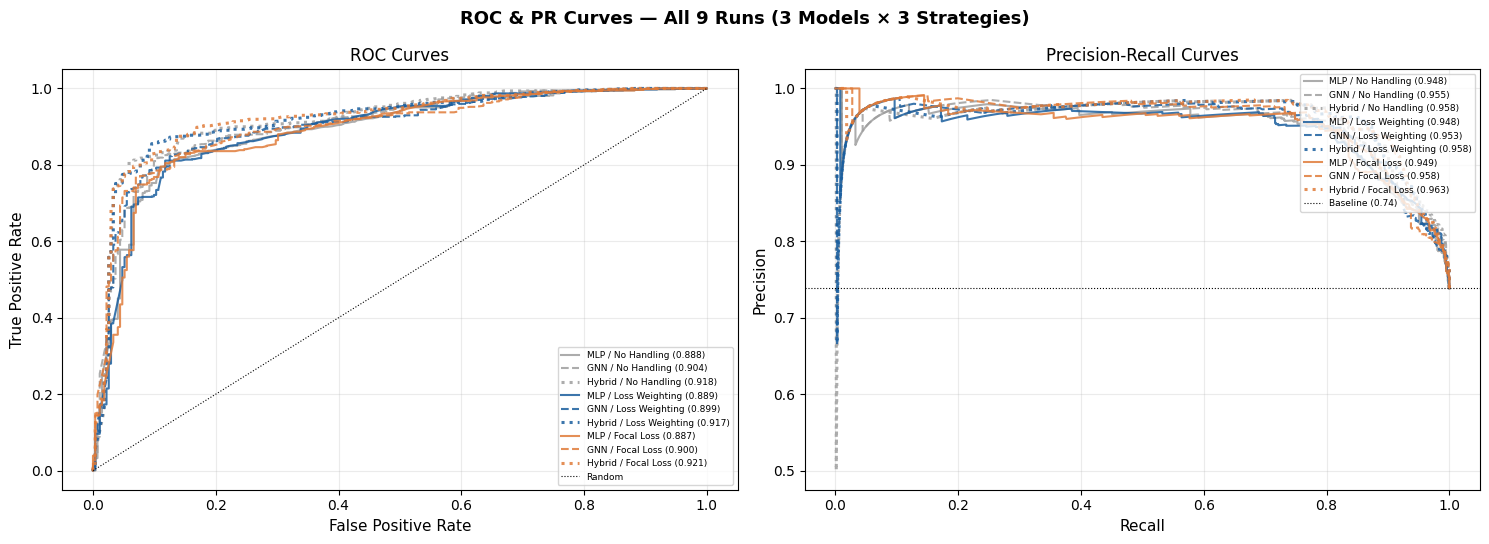

Figure 3 saved.


In [17]:
LINE_STYLES = {'MLP': '-', 'GNN': '--', 'Hybrid': ':'}
LINE_WIDTH  = {'MLP': 1.5, 'GNN': 1.5, 'Hybrid': 2.2}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('ROC & PR Curves — All 9 Runs (3 Models × 3 Strategies)',
             fontsize=13, fontweight='bold')

for strat in STRATEGIES:
    for model in MODEL_LIST:
        m   = ALL_RESULTS[strat][model]
        lbl = f'{model} / {strat}'

        fpr, tpr, _ = roc_curve(m['y_true'], m['probs'])
        axes[0].plot(fpr, tpr,
                     linestyle=LINE_STYLES[model],
                     color=STRAT_COLORS[strat],
                     linewidth=LINE_WIDTH[model],
                     alpha=0.85,
                     label=f"{lbl} ({m['ROC-AUC']:.3f})")

        p, r, _ = precision_recall_curve(m['y_true'], m['probs'])
        axes[1].plot(r, p,
                     linestyle=LINE_STYLES[model],
                     color=STRAT_COLORS[strat],
                     linewidth=LINE_WIDTH[model],
                     alpha=0.85,
                     label=f"{lbl} ({m['PR-AUC']:.3f})")

axes[0].plot([0,1],[0,1], 'k:', linewidth=0.8, label='Random')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate',  fontsize=11)
axes[0].set_title('ROC Curves')
axes[0].legend(fontsize=6.5, loc='lower right')
axes[0].grid(alpha=0.25)

baseline_pr = (Y_TEST == 1).mean()
axes[1].axhline(y=baseline_pr, color='k', linestyle=':', linewidth=0.8, label=f'Baseline ({baseline_pr:.2f})')
axes[1].set_xlabel('Recall',    fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(fontsize=6.5, loc='upper right')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/junior_project/fig3_roc_pr_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

## CELL 18 — Figure 4: Metric Heatmap (report highlight figure)

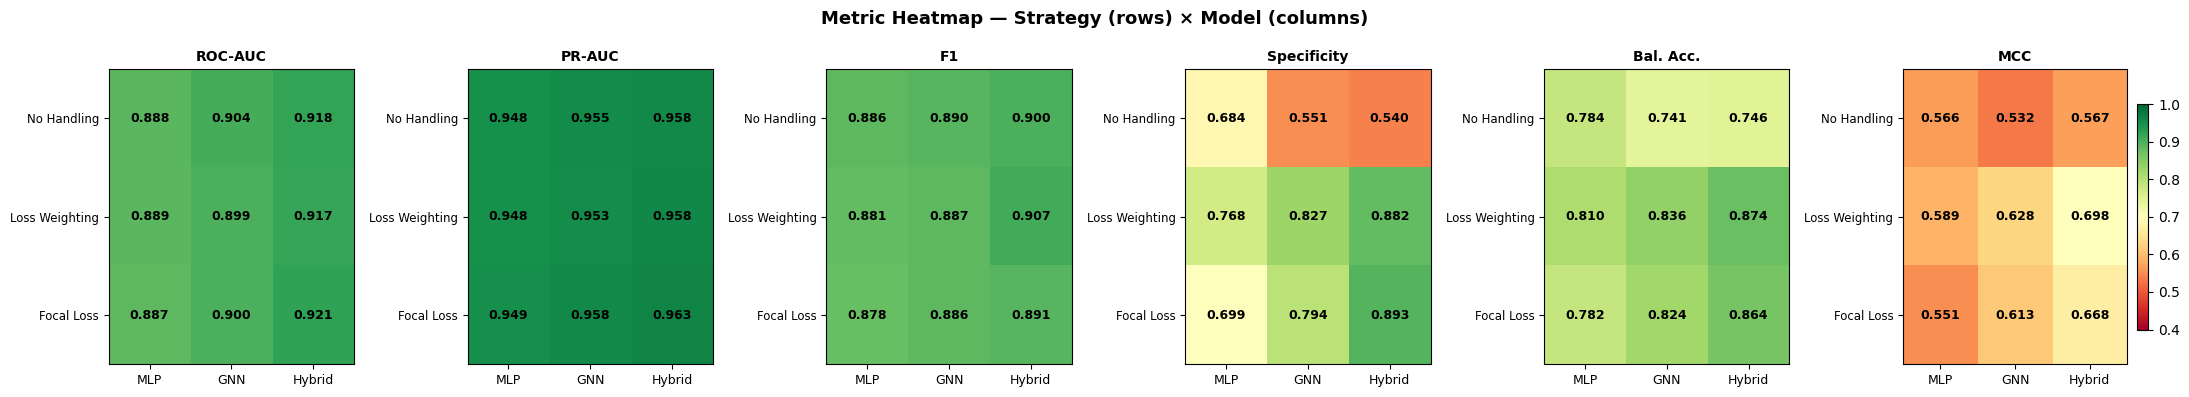

Figure 4 saved.


In [18]:
# ── Key metrics for report heatmap ───────────────────────────────────
heat_metrics  = ['ROC-AUC', 'PR-AUC', 'F1', 'Specificity', 'Bal_Acc', 'MCC']
heat_labels   = ['ROC-AUC', 'PR-AUC', 'F1', 'Specificity', 'Bal. Acc.', 'MCC']

fig, axes = plt.subplots(1, len(heat_metrics), figsize=(22, 4.0))
fig.suptitle('Metric Heatmap — Strategy (rows) × Model (columns)',
             fontsize=13, fontweight='bold')

for ax, metric, mlabel in zip(axes, heat_metrics, heat_labels):
    mat = np.array([[ALL_RESULTS[s][m][metric] for m in MODEL_LIST]
                    for s in STRATEGIES])
    im = ax.imshow(mat, vmin=0.40, vmax=1.0, cmap='RdYlGn', aspect='auto')
    ax.set_xticks(range(len(MODEL_LIST)));   ax.set_xticklabels(MODEL_LIST, fontsize=9)
    ax.set_yticks(range(len(STRATEGIES)));   ax.set_yticklabels(STRATEGIES, fontsize=8.5)
    ax.set_title(mlabel, fontsize=10, fontweight='bold')
    for i in range(len(STRATEGIES)):
        for j in range(len(MODEL_LIST)):
            ax.text(j, i, f'{mat[i,j]:.3f}', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='black')

plt.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/junior_project/fig4_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

## CELL 19 — Figure 5: Confusion Matrices (Hybrid model)

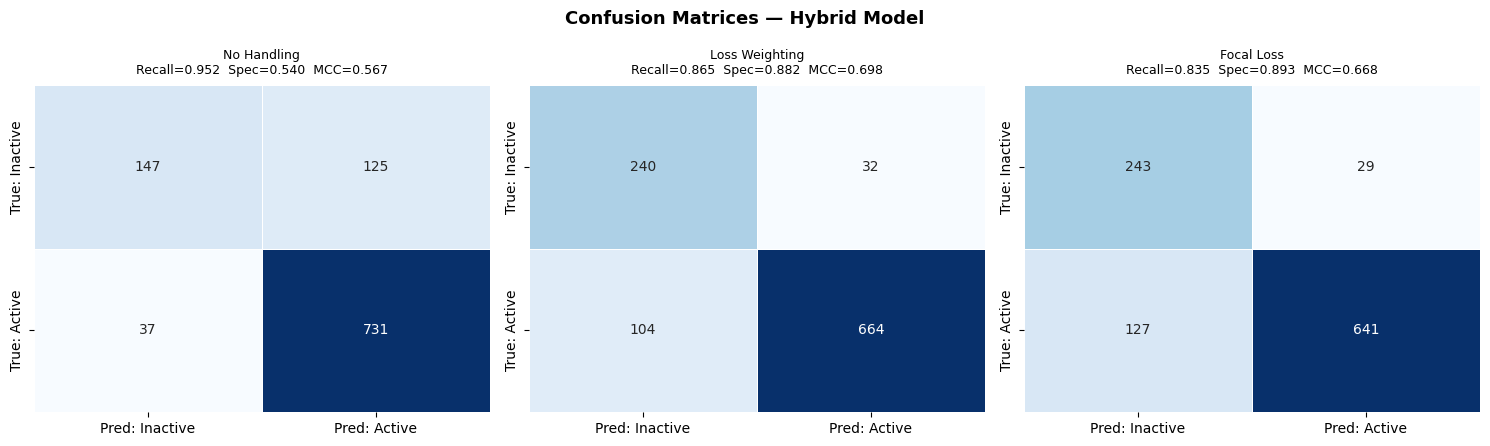

Figure 5 saved.


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Confusion Matrices — Hybrid Model',
             fontsize=13, fontweight='bold')

for ax, strat in zip(axes, STRATEGIES):
    m  = ALL_RESULTS[strat]['Hybrid']
    cm = np.array([[m['TN'], m['FP']],
                   [m['FN'], m['TP']]])

    # Normalize for color, show raw counts as text
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Pred: Inactive', 'Pred: Active'],
                yticklabels=['True: Inactive', 'True: Active'],
                linewidths=0.5)

    ax.set_title(
        f'{strat}\n'
        f'Recall={m["Recall"]:.3f}  Spec={m["Specificity"]:.3f}  MCC={m["MCC"]:.3f}',
        fontsize=9, pad=8
    )

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/junior_project/fig5_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

## CELL 20 — Figure 6: Loss Weighting Gain over No Handling (delta plot)

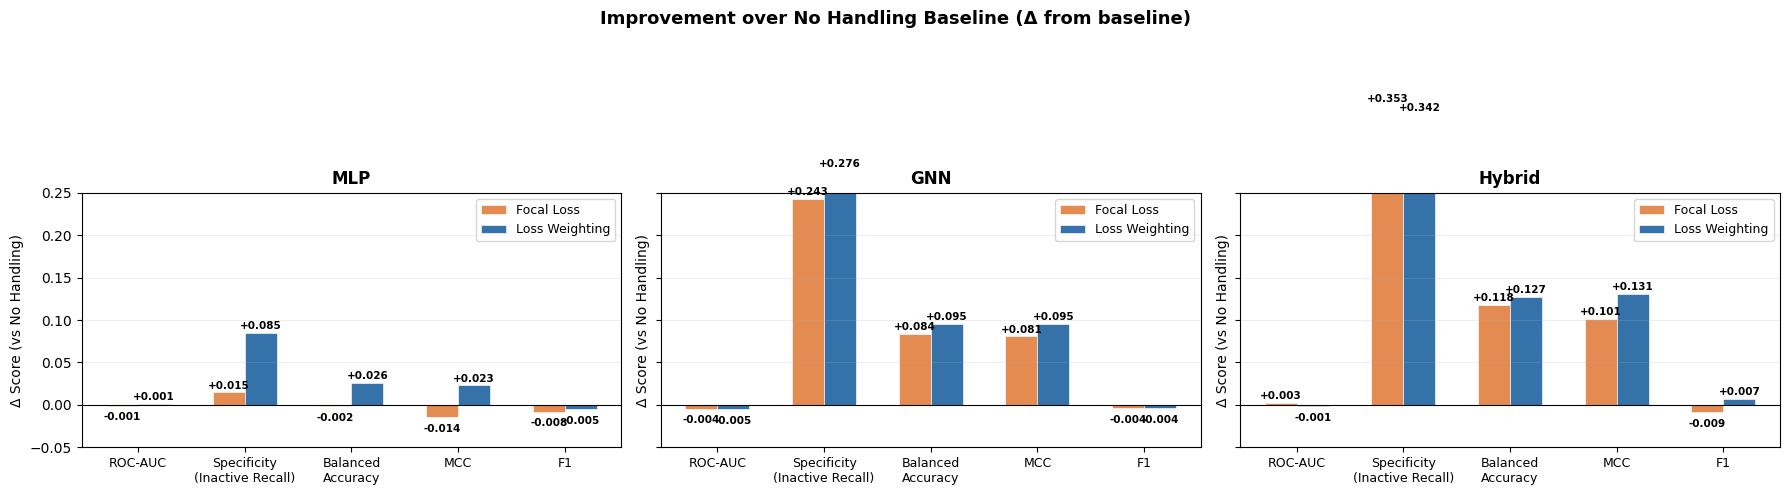

Figure 6 saved — this is your key result figure.


In [20]:
# ── Delta plot: how much does each strategy GAIN vs No Handling? ──────
# This is the single clearest figure to show Loss Weighting is best.

delta_metrics = ['ROC-AUC', 'Specificity', 'Bal_Acc', 'MCC', 'F1']
delta_labels  = ['ROC-AUC', 'Specificity\n(Inactive Recall)', 'Balanced\nAccuracy', 'MCC', 'F1']
compare_strats = ['Focal Loss', 'Loss Weighting']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Improvement over No Handling Baseline (Δ from baseline)',
             fontsize=13, fontweight='bold')

x_d = np.arange(len(delta_metrics))
w_d = 0.30

for ax, model in zip(axes, MODEL_LIST):
    base = {k: ALL_RESULTS['No Handling'][model][k] for k in delta_metrics}
    for j, strat in enumerate(compare_strats):
        deltas = [ALL_RESULTS[strat][model][k] - base[k] for k in delta_metrics]
        bars   = ax.bar(x_d + (j - 0.5) * w_d, deltas, w_d,
                        label=strat, color=STRAT_COLORS[strat],
                        alpha=0.88, edgecolor='white', linewidth=0.5)
        # Annotate with +/- value
        for bar, d in zip(bars, deltas):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (0.002 if d >= 0 else -0.008),
                    f'{d:+.3f}', ha='center', va='bottom' if d >= 0 else 'top',
                    fontsize=7.5, fontweight='bold')

    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
    ax.set_title(model, fontweight='bold', fontsize=12)
    ax.set_xticks(x_d)
    ax.set_xticklabels(delta_labels, fontsize=9)
    ax.set_ylabel('Δ Score (vs No Handling)')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)
    ax.set_ylim(-0.05, 0.25)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/junior_project/fig6_delta_improvement.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved — this is your key result figure.')

---
## CELL 21 — Summary Statistics for Report

Print the exact numbers you need for your Progress Report 2 narrative.

In [21]:
print('=' * 70)
print('SUMMARY FOR PROGRESS REPORT 2')
print('=' * 70)

for model in MODEL_LIST:
    print(f'\n--- {model} ---')
    base  = ALL_RESULTS['No Handling'][model]
    lw    = ALL_RESULTS['Loss Weighting'][model]
    fl    = ALL_RESULTS['Focal Loss'][model]

    spec_gain_lw = (lw['Specificity'] - base['Specificity']) * 100
    spec_gain_fl = (fl['Specificity'] - base['Specificity']) * 100
    mcc_gain_lw  = (lw['MCC'] - base['MCC']) * 100

    print(f'  Specificity:  No Handling={base["Specificity"]:.3f}  '
          f'Focal Loss={fl["Specificity"]:.3f}  '
          f'Loss Weighting={lw["Specificity"]:.3f}  '
          f'[+{spec_gain_lw:.1f}% over baseline]')
    print(f'  Balanced Acc: No Handling={base["Bal_Acc"]:.3f}  '
          f'Focal Loss={fl["Bal_Acc"]:.3f}  '
          f'Loss Weighting={lw["Bal_Acc"]:.3f}')
    print(f'  MCC:          No Handling={base["MCC"]:.3f}  '
          f'Focal Loss={fl["MCC"]:.3f}  '
          f'Loss Weighting={lw["MCC"]:.3f}  '
          f'[+{mcc_gain_lw:.1f}pp over baseline]')
    print(f'  ROC-AUC:      No Handling={base["ROC-AUC"]:.3f}  '
          f'Focal Loss={fl["ROC-AUC"]:.3f}  '
          f'Loss Weighting={lw["ROC-AUC"]:.3f}')

print('\n' + '=' * 70)
print('Best overall model:')
best_row = results_df.loc[results_df['MCC'].idxmax()]
print(f'  {best_row["Strategy"]} / {best_row["Model"]}  '
      f'MCC={best_row["MCC"]:.4f}  '
      f'ROC-AUC={best_row["ROC-AUC"]:.4f}  '
      f'Specificity={best_row["Specificity"]:.4f}')

print('\nAll results saved to model_results_v2.csv')
print('All figures saved to /content/drive/MyDrive/junior_project/')

SUMMARY FOR PROGRESS REPORT 2

--- MLP ---
  Specificity:  No Handling=0.684  Focal Loss=0.699  Loss Weighting=0.768  [+8.5% over baseline]
  Balanced Acc: No Handling=0.784  Focal Loss=0.782  Loss Weighting=0.810
  MCC:          No Handling=0.566  Focal Loss=0.551  Loss Weighting=0.589  [+2.3pp over baseline]
  ROC-AUC:      No Handling=0.888  Focal Loss=0.887  Loss Weighting=0.889

--- GNN ---
  Specificity:  No Handling=0.551  Focal Loss=0.794  Loss Weighting=0.827  [+27.6% over baseline]
  Balanced Acc: No Handling=0.741  Focal Loss=0.824  Loss Weighting=0.836
  MCC:          No Handling=0.532  Focal Loss=0.613  Loss Weighting=0.628  [+9.5pp over baseline]
  ROC-AUC:      No Handling=0.904  Focal Loss=0.900  Loss Weighting=0.899

--- Hybrid ---
  Specificity:  No Handling=0.540  Focal Loss=0.893  Loss Weighting=0.882  [+34.2% over baseline]
  Balanced Acc: No Handling=0.746  Focal Loss=0.864  Loss Weighting=0.874
  MCC:          No Handling=0.567  Focal Loss=0.668  Loss Weighting=0